# ============================================================
# EDA — Primary Dataset
# ============================================================
 Goal:
Analyse the Kaggle/Datafiniti primary dataset before merging it
with the larger Amazon Reviews 2023 dataset.

This helps us understand:
- class imbalance
- product concentration
- category concentration
- review length patterns
- whether the primary dataset is enough on its own
============================================================

In [1]:
import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
BASE_DIR = os.getcwd()

if os.path.basename(BASE_DIR) == "EDA":
    BASE_DIR = os.path.dirname(BASE_DIR)

PRIMARY_DIR = os.path.join(BASE_DIR, "data", "primary")

expected_files = [
    "1429_1.csv",
    "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv",
    "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"
]

print("Working directory:", os.getcwd())
print("Primary directory:", PRIMARY_DIR)
print("Primary directory exists:", os.path.exists(PRIMARY_DIR))

Working directory: /Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/EDA
Primary directory: /Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/data/primary
Primary directory exists: True


In [3]:
# Output folder for Primary EDA plots

OUTPUT_DIR = os.path.join(BASE_DIR, "EDA", "eda_outputs", "primary_eda_outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Plots will be saved in:")

print(OUTPUT_DIR)

Plots will be saved in:
/Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/EDA/eda_outputs/primary_eda_outputs


1. Checks that we are really using all files from primary dataset

In [4]:
files = []

for name in expected_files:
    path = os.path.join(PRIMARY_DIR, name)
    if os.path.exists(path):
        files.append(path)

if not files:
    files = glob.glob(os.path.join(PRIMARY_DIR, "*.csv")) + glob.glob(os.path.join(PRIMARY_DIR, "*.tsv"))

print("Files found:")
for f in files:
    print("-", os.path.basename(f))

if not files:
    raise FileNotFoundError(f"No CSV/TSV files found in {PRIMARY_DIR}")

Files found:
- 1429_1.csv
- Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
- Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [5]:
def find_col(df, options):
    for col in options:
        if col in df.columns:
            return col
    return None

text_options = ["reviews.text", "review_text", "text", "reviewText", "reviews"]
rating_options = ["reviews.rating", "rating", "overall", "stars", "reviews.stars"]
product_options = ["name", "product_name", "title", "asins", "asin"]
category_options = ["categories", "primaryCategories", "category", "main_cat"]

In [6]:
audit = []

for path in files:
    sep = "	" if path.endswith(".tsv") else ","
    temp = pd.read_csv(path, sep=sep, low_memory=False)

    audit.append({
        "file": os.path.basename(path),
        "rows": temp.shape[0],
        "cols": temp.shape[1],
        "text_col": find_col(temp, text_options),
        "rating_col": find_col(temp, rating_options),
        "product_col": find_col(temp, product_options),
        "category_col": find_col(temp, category_options)
    })

audit_df = pd.DataFrame(audit)
audit_df["usable"] = audit_df["text_col"].notna() & audit_df["rating_col"].notna()

display(audit_df)

,file,rows,cols,text_col,rating_col,product_col,category_col,usable
0,1429_1.csv,34660,21,reviews.text,reviews.rating,name,categories,True
1,Datafiniti_Amazon_Consumer_Reviews_of_Amazon_P...,5000,24,reviews.text,reviews.rating,name,categories,True
2,Datafiniti_Amazon_Consumer_Reviews_of_Amazon_P...,28332,24,reviews.text,reviews.rating,name,categories,True


2. Load primary Dataset

In [7]:
def clean_text_basic(x):
    if pd.isna(x):
        return ""
    x = str(x).replace(" ", " ").replace(" ", " ").replace("	", " ")
    x = re.sub(r"<.*?>", " ", x)
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def clean_category(x):
    if pd.isna(x):
        return "Unknown Category"
    x = str(x).replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    x = re.sub(r"\s+", " ", x).strip()
    if "," in x:
        x = x.split(",")[0].strip()
    return x if x else "Unknown Category"


def rating_to_sentiment(rating):
    try:
        rating = float(rating)
    except Exception:
        return np.nan
    if rating <= 2:
        return "negative"
    if rating == 3:
        return "neutral"
    if rating >= 4:
        return "positive"
    return np.nan

3. Basic Checks

In [9]:
# Load primary dataset

all_data = []

for file in files:
    df = pd.read_csv(file, low_memory=False)

    df["source_file"] = os.path.basename(file)

    if "reviews.text" in df.columns:
        text_col = "reviews.text"
    elif "review_text" in df.columns:
        text_col = "review_text"
    else:
        text_col = None

    if "reviews.rating" in df.columns:
        rating_col = "reviews.rating"
    elif "rating" in df.columns:
        rating_col = "rating"
    else:
        rating_col = None

    if "name" in df.columns:
        product_col = "name"
    elif "product_name" in df.columns:
        product_col = "product_name"
    else:
        product_col = None

    if "categories" in df.columns:
        category_col = "categories"
    elif "primaryCategories" in df.columns:
        category_col = "primaryCategories"
    else:
        category_col = None

    temp = pd.DataFrame()

    temp["review_text"] = df[text_col].apply(clean_text_basic) if text_col else ""
    temp["rating"] = pd.to_numeric(df[rating_col], errors="coerce") if rating_col else np.nan
    temp["product_name"] = df[product_col] if product_col else "Unknown Product"
    temp["raw_category"] = df[category_col].apply(clean_category) if category_col else "Unknown Category"
    temp["source_file"] = df["source_file"]

    all_data.append(temp)

primary_df = pd.concat(all_data, ignore_index=True)

primary_df = primary_df.dropna(subset=["review_text", "rating"])
primary_df = primary_df[primary_df["review_text"].str.strip() != ""]

primary_df["sentiment"] = primary_df["rating"].apply(rating_to_sentiment)

primary_df = primary_df.dropna(subset=["sentiment"])

print("Primary dataset loaded")
print("Shape:", primary_df.shape)

display(primary_df.head())

Primary dataset loaded
Shape: (67957, 6)


,review_text,rating,product_name,raw_category,source_file,sentiment
0,This product so far has not disappointed. My c...,5.0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Electronics,1429_1.csv,positive
1,great for beginner or experienced person. Boug...,5.0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Electronics,1429_1.csv,positive
2,Inexpensive tablet for him to use and learn on...,5.0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Electronics,1429_1.csv,positive
3,I've had my Fire HD 8 two weeks now and I love...,4.0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Electronics,1429_1.csv,positive
4,I bought this for my grand daughter when she c...,5.0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Electronics,1429_1.csv,positive


In [10]:
print("Rows by file")
display(primary_df["source_file"].value_counts().to_frame("rows"))

print("Missing values")
cols = ["review_text", "rating", "product_name", "raw_category", "sentiment", "source_file"]
missing = primary_df[cols].isna().sum().to_frame("missing")
missing["pct"] = (missing["missing"] / len(primary_df) * 100).round(2)
display(missing)

Rows by file


,rows
source_file,
1429_1.csv,34625
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv,28332
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv,5000


Missing values


,missing,pct
review_text,0,0.00
rating,0,0.00
product_name,6759,9.95
raw_category,0,0.00
sentiment,0,0.00
source_file,0,0.00


In [11]:
dup_cols = ["review_text", "rating", "product_name"]
duplicates = primary_df.duplicated(subset=dup_cols).sum()

print("Duplicate rows:", duplicates)
print("Duplicate %:", round(duplicates / len(primary_df) * 100, 2))

Duplicate rows: 3785
Duplicate %: 5.57


4. Rating and Sentiment

,count,pct
rating,,
1.0,1438,2.12
2.0,1072,1.58
3.0,2902,4.27
4.0,15397,22.66
5.0,47148,69.38


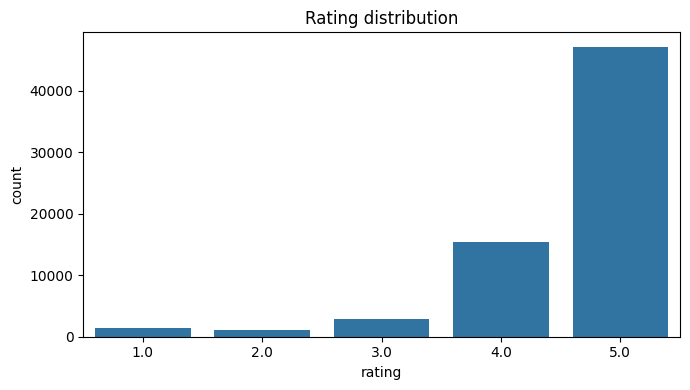

In [12]:
rating_dist = primary_df["rating"].value_counts(dropna=False).sort_index().to_frame("count")
rating_dist["pct"] = (rating_dist["count"] / len(primary_df) * 100).round(2)
display(rating_dist)

plt.figure(figsize=(7, 4))
sns.countplot(data=primary_df, x="rating")
plt.title("Rating distribution")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rating_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

,count,pct
sentiment,,
negative,2510,3.69
neutral,2902,4.27
positive,62545,92.04


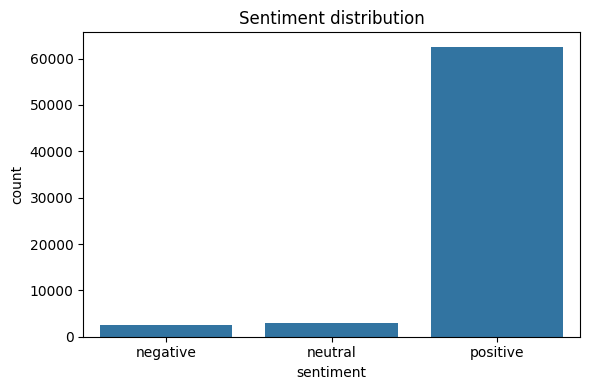

In [13]:
sentiment_order = ["negative", "neutral", "positive"]

sentiment_dist = primary_df["sentiment"].value_counts().reindex(sentiment_order).to_frame("count")
sentiment_dist["pct"] = (sentiment_dist["count"] / len(primary_df) * 100).round(2)
display(sentiment_dist)

plt.figure(figsize=(6, 4))
sns.countplot(data=primary_df, x="sentiment", order=sentiment_order)
plt.title("Sentiment distribution")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

sentiment,negative,neutral,positive
source_file,,,
1429_1.csv,2.35,4.33,93.33
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv,2.34,3.94,93.72
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv,5.58,4.26,90.16


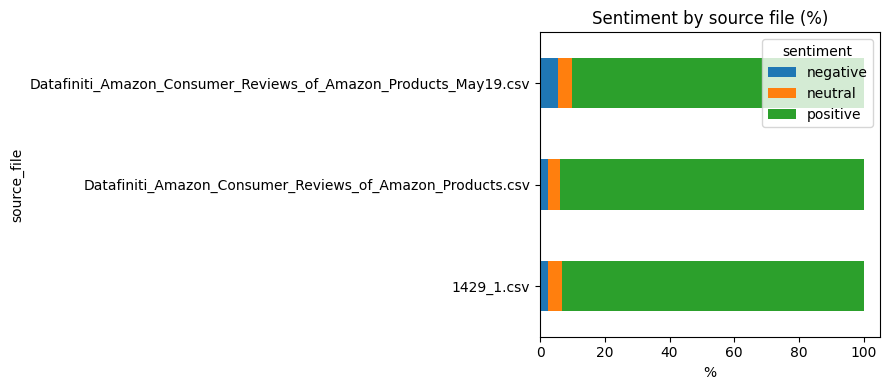

In [14]:
by_file = pd.crosstab(
    primary_df["source_file"],
    primary_df["sentiment"],
    normalize="index"
).reindex(columns=sentiment_order).fillna(0)

display((by_file * 100).round(2))

(by_file * 100).plot(kind="barh", stacked=True, figsize=(9, 4))
plt.title("Sentiment by source file (%)")
plt.xlabel("%")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_by_source_file.png"), dpi=300, bbox_inches="tight")
plt.show()

5. Products and Categories

,reviews,pct
product_name,,
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",10962,16.13
AmazonBasics AAA Performance Alkaline Batteries (36 Count),8343,12.28
AmazonBasics AA Performance Alkaline Batteries (48 Count) - Packaging May Vary,3728,5.49
"Echo (White),,,\r\nEcho (White),,,",3309,4.87
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",3176,4.67
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",3114,4.58
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",2814,4.14
"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",2527,3.72
"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers",2443,3.59


) missing from font(s) DejaVu Sans.5zq7m0000gn/T/ipykernel_5051/926420030.py:9: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.5zq7m0000gn/T/ipykernel_5051/926420030.py:10: UserWarning: Glyph 13 (
  plt.savefig(os.path.join(OUTPUT_DIR, "top_products.png"), dpi=300, bbox_inches="tight")
) missing from font(s) DejaVu Sans.-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


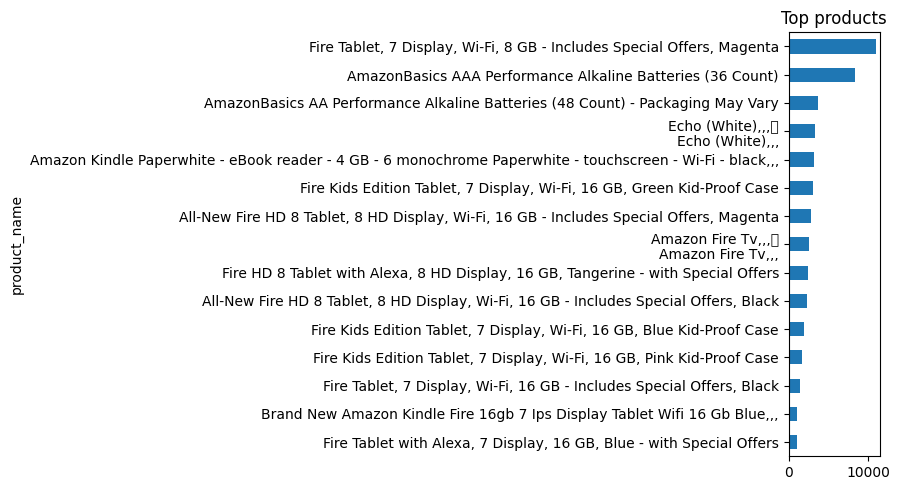

In [15]:
top_products = primary_df["product_name"].value_counts().head(15).to_frame("reviews")
top_products["pct"] = (top_products["reviews"] / len(primary_df) * 100).round(2)
display(top_products)

plt.figure(figsize=(9, 5))
top_products["reviews"].sort_values().plot(kind="barh")
plt.title("Top products")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_products.png"), dpi=300, bbox_inches="tight")
plt.show()

,reviews,pct
raw_category,,
Fire Tablets,24883,36.62
AA,12071,17.76
Stereos,6621,9.74
Back To College,5056,7.44
Electronics,4155,6.11
Walmart for Business,3756,5.53
Computers,2749,4.05
Tablets,2051,3.02
Amazon Echo,1632,2.40


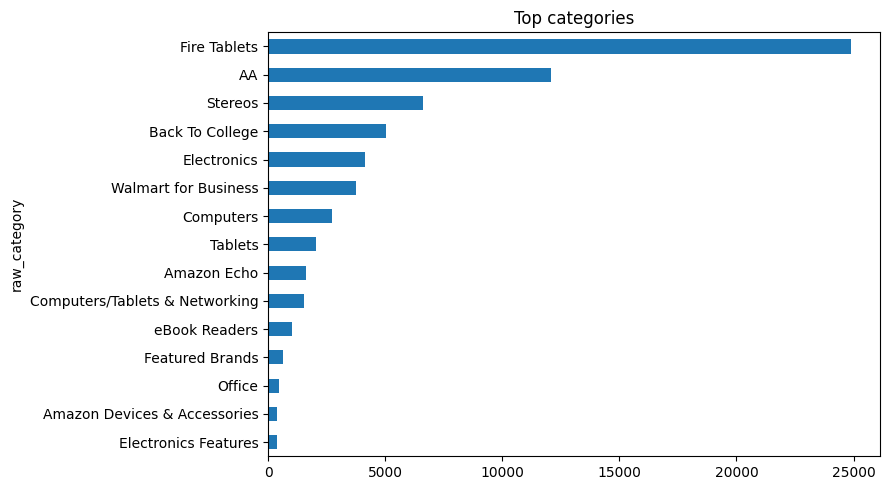

In [16]:
top_categories = primary_df["raw_category"].value_counts().head(15).to_frame("reviews")
top_categories["pct"] = (top_categories["reviews"] / len(primary_df) * 100).round(2)
display(top_categories)

plt.figure(figsize=(9, 5))
top_categories["reviews"].sort_values().plot(kind="barh")
plt.title("Top categories")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_categories.png"), dpi=300, bbox_inches="tight")
plt.show()

6. Review Length

In [18]:
# Create review length columns

primary_df["review_char_count"] = primary_df["review_text"].astype(str).apply(len)
primary_df["review_word_count"] = primary_df["review_text"].astype(str).apply(lambda x: len(x.split()))

display(primary_df[["review_text", "review_char_count", "review_word_count"]].head())

,review_text,review_char_count,review_word_count
0,This product so far has not disappointed. My c...,143,27
1,great for beginner or experienced person. Boug...,75,14
2,Inexpensive tablet for him to use and learn on...,131,26
3,I've had my Fire HD 8 two weeks now and I love...,593,117
4,I bought this for my grand daughter when she c...,613,117


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,2510.0,42.50,42.37,1.0,14.0,28.0,59.0,423.0
neutral,2902.0,35.42,38.55,1.0,14.0,23.0,44.0,407.0
positive,62545.0,27.62,35.81,1.0,12.0,19.0,32.0,1858.0


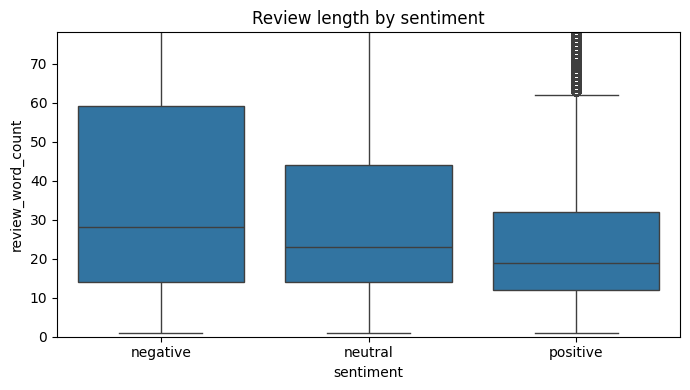

In [19]:
display(primary_df.groupby("sentiment")["review_word_count"].describe().round(2))

plt.figure(figsize=(7, 4))
sns.boxplot(data=primary_df, x="sentiment", y="review_word_count", order=sentiment_order)
plt.ylim(0, primary_df["review_word_count"].quantile(0.95))
plt.title("Review length by sentiment")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "review_length_by_sentiment.png"), dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Final summary

summary_df = pd.DataFrame({
    "metric": [
        "rows",
        "files_used",
        "duplicate_rows",
        "majority_sentiment",
        "neutral_reviews",
        "usable_rows_for_modelling"
    ],
    "value": [
        len(primary_df),
        primary_df["source_file"].nunique(),
        duplicates,
        primary_df["sentiment"].value_counts().idxmax(),
        int((primary_df["sentiment"] == "neutral").sum()),
        primary_df.dropna(subset=["review_text", "rating", "sentiment"]).shape[0]
    ]
})

display(summary_df)

summary_path = os.path.join(OUTPUT_DIR, "primary_eda_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("Summary saved in:")
print(summary_path)

,metric,value
0,rows,67957
1,files_used,3
2,duplicate_rows,3785
3,majority_sentiment,positive
4,neutral_reviews,2902
5,usable_rows_for_modelling,67957


Summary saved in:
/Users/marcelocorreia/Desktop/Project_2/project-nlp-business-case-automated-customers-reviews-v2/EDA/eda_outputs/primary_eda_outputs/primary_eda_summary.csv
